In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from os.path import join
%matplotlib inline
import seaborn as sns
from PSPupil import Preprocessing as PS
from PSPupil import dataset as dt
from decim.adjuvant import slurm_submit as slu

from sklearn.metrics import roc_curve, roc_auc_score



In [58]:
def roc_auc_by_group(
    df: pd.DataFrame,
    x_col: str = "x",
    group_col: str = "group",
    positive_label: str = "A",
    compare_against=("B", "C"),
    compute_optimal_threshold: bool = True,
    auto_orient_scores: bool = True,
    plot: bool = True,
):
    """
    ROC + AUC for distinguishing `positive_label` vs each group in `compare_against`
    using the numeric score in `x_col`. The reported optimal threshold is ALWAYS on
    the ORIGINAL x-scale, with the correct inequality.

    Returns
    -------
    results: dict keyed by target group, each with:
        - auc
        - fpr, tpr, thresholds_on_score (the raw ROC outputs)
        - threshold_on_x (optimal cutoff on original x scale)
        - rule (string like "predict A if x >= T" or "predict A if x <= T")
        - sensitivity, specificity at that cutoff
        - orientation ('higher_x_is_A' True/False)
    """
    # basic checks
    if x_col not in df.columns or group_col not in df.columns:
        raise ValueError(f"DataFrame must contain '{x_col}' and '{group_col}'.")
    if positive_label not in set(df[group_col]):
        raise ValueError(f"Positive label '{positive_label}' not found in '{group_col}'.")

    use_groups = {positive_label, *compare_against}
    work = df[df[group_col].isin(use_groups)][[x_col, group_col]].dropna().copy()

    results = {}
    if plot:
        plt.figure(figsize=(7, 5))

    for neg in compare_against:
        sub = work[work[group_col].isin([positive_label, neg])].copy()
        if sub.empty:
            raise ValueError(f"No rows for comparison {positive_label} vs {neg}.")

        y_true = (sub[group_col] == positive_label).astype(int).to_numpy()
        x = sub[x_col].astype(float).to_numpy()

        # Start with original orientation (higher x -> predict A)
        sign = 1.0
        y_score = sign * x
        fpr, tpr, thr_used = roc_curve(y_true, y_score)
        auc_val = roc_auc_score(y_true, y_score)

        # If AUC < 0.5 and allowed, flip orientation for ROC computation
        if auto_orient_scores and auc_val < 0.5:
            sign = -1.0
            y_score = sign * x  # now y_score = -x
            fpr, tpr, thr_used = roc_curve(y_true, y_score)
            auc_val = roc_auc_score(y_true, y_score)

        entry = {
            "fpr": fpr,
            "tpr": tpr,
            "thresholds_on_score": thr_used,
            "auc": float(auc_val),
            "orientation": bool(sign > 0),  # True => higher x favors A
        }

        if compute_optimal_threshold:
            # Youden's J
            j = tpr - fpr

            # Ignore the first threshold (often inf) and any non-finite thresholds
            valid = np.isfinite(thr_used)
            if valid.sum() == 0:
                idx = int(np.argmax(j))  # fallback, but should rarely happen
            else:
                j_masked = np.where(valid, j, -np.inf)
                idx = int(np.argmax(j_masked))

            thr_score = float(thr_used[idx])  # threshold on the possibly flipped score

            # Convert the optimal threshold back to the ORIGINAL x scale
            # If sign == +1: predict A if x >= thr_score
            # If sign == -1: rule on score is (-x) >= thr_score  =>  x <= -thr_score
            if sign > 0:
                thr_x = thr_score
                rule = f"predict {positive_label} if {x_col} >= {thr_x:.6g}"
            else:
                thr_x = -thr_score
                rule = f"predict {positive_label} if {x_col} <= {thr_x:.6g}"

            sens = float(tpr[idx])
            spec = float(1 - fpr[idx])

            entry.update({
                "threshold_on_x": float(thr_x),
                "rule": rule,
                "sensitivity": sens,
                "specificity": spec,
                "youden_J": float(j[idx]),
            })

        results[neg] = entry

        if plot:
            plt.plot(fpr, tpr, label=f"{positive_label} vs {neg} (AUC = {auc_val:.3f})")

    if plot:
        plt.plot([0, 1], [0, 1], linestyle="--", color='black')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC curves")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return results


In [3]:
edition = '/Volumes/psp_data/PSP/Pupil_Preprocessed_2024-06-17/' # FOOOF, no z-scoring

condition = 'bp_non_normalized'

In [4]:
auc = pd.read_hdf(join(edition, 'PowerFrequencies', 'auc_bp_non_normalized.hdf'), key='data')
psp_baseline_auc = auc.loc[(auc.group == 'PSP')&(auc.session == 'Baseline')]
cov = pd.read_hdf(join(edition, 'PowerFrequencies', 'CoV.hdf'), key='data')
cov = cov.loc[cov.condition == 'bp_non_normalized']
cov = cov.groupby(['group', 'session', 'subject']).mean().reset_index()
cov['cov']= cov.loc[:, 'std'] / cov.loc[:, 'mean']
fooof = pd.read_hdf(join(edition, 'SPECPARAMS', 'Specparams_2024-06-18.hdf'), key= 'data')


### Exclude PD subject 12
cov = cov.set_index(['group', 'subject']).drop(('PD', '12')).reset_index()
fooof = fooof.set_index(['group', 'subject']).drop(('PD', '12')).reset_index()
auc = auc.set_index(['group', 'subject']).drop(('PD', '12')).reset_index()

In [42]:
cov = cov.loc[(cov.group.isin(['Control', 'PSP', 'PD']))&(cov.session == 'Baseline')]

## ROC & AUC for CoV

In [44]:
# check data
cov

,group,subject,session,mean,std,cov
0,Control,02,Baseline,80.823564,2.782674,3.442900
1,Control,03,Baseline,58.243589,5.677259,9.747439
2,Control,04,Baseline,63.602579,2.557453,4.020990
3,Control,05,Baseline,52.392027,6.977418,13.317710
4,Control,06,Baseline,70.563691,5.251161,7.441732
5,Control,07,Baseline,55.361864,8.367539,15.114265
6,Control,08,Baseline,45.193887,3.833152,8.481571
7,Control,09,Baseline,78.512623,4.455149,5.674436
8,Control,10,Baseline,47.108782,4.133838,8.775090
9,Control,11,Baseline,58.603257,2.774530,4.734429


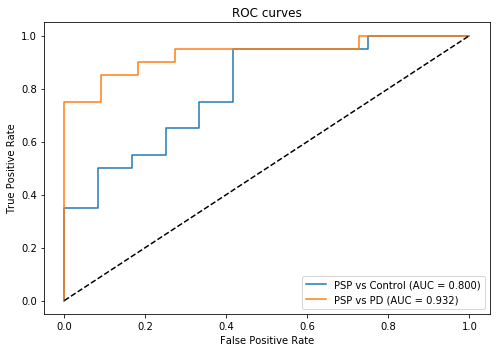

In [59]:
results = roc_auc_by_group(cov, x_col="cov", group_col="group", positive_label='PSP', compare_against=['Control', 'PD'])


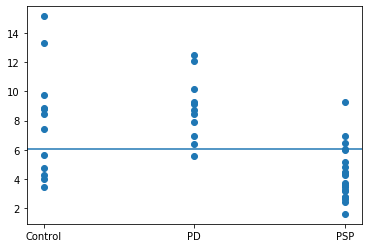

In [45]:
plt.scatter(cov['group'], cov['cov'])
plt.axhline(results['PD']['threshold_on_x']*100)

## ROC for AUC

In [49]:
auc = auc.loc[(auc.group.isin(['PSP', 'PD', 'Control']))&(auc.session == 'Baseline')]

In [51]:
auc.shape

(43, 5)

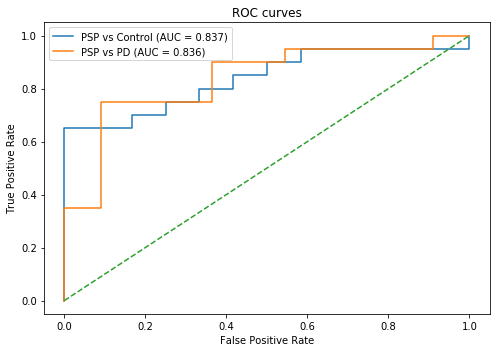

In [53]:
results = roc_auc_by_group(auc, x_col="auc", group_col="group", positive_label='PSP', compare_against=['Control', 'PD'])


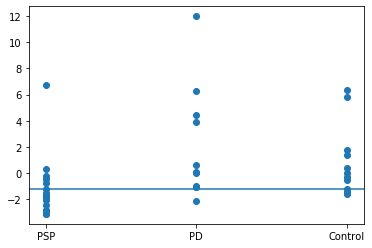

In [55]:
plt.scatter(auc['group'], auc['auc'])
plt.axhline(results['PD']['threshold_on_x'])

In [60]:
cov

,group,subject,session,mean,std,cov
0,Control,02,Baseline,80.823564,2.782674,3.442900
1,Control,03,Baseline,58.243589,5.677259,9.747439
2,Control,04,Baseline,63.602579,2.557453,4.020990
3,Control,05,Baseline,52.392027,6.977418,13.317710
4,Control,06,Baseline,70.563691,5.251161,7.441732
5,Control,07,Baseline,55.361864,8.367539,15.114265
6,Control,08,Baseline,45.193887,3.833152,8.481571
7,Control,09,Baseline,78.512623,4.455149,5.674436
8,Control,10,Baseline,47.108782,4.133838,8.775090
9,Control,11,Baseline,58.603257,2.774530,4.734429
